# Solving the Traveling Salesman  Problem using Local Search

Points: 10

## The Traveling Salesman Problem

Problem definition (see [TSP on Wikipedia](https://en.wikipedia.org/wiki/Travelling_salesman_problem)):

* __Goal:__ Find the shortest tour visiting each of $n$ cities exactly once and returning back to the starting city. Given are pairwise distances between cities, where $d_{i,j}$ is the distance from city $i$ to city $j$.

* __State space:__ Each state represents a tour. The cities are numbered and a tour can be expressed as vector  $\pi$ with the order in which the cities are visited (a [permutation](https://en.wikipedia.org/wiki/Permutation)). That is, $\pi(1)$ is the index of the first city to visit, $\pi(2)$ the index of the second, and so on.

* __Objective function:__ Minimize the tour length. The optimization problem is to find the optimal tour $\pi^*$ through the $n$ cities and returning to the starting city:

  > minimize: $\mathrm{tourlength}(\pi) = d_{\pi(n),\pi(1)} + \sum_{i = 1}^{n-1} d_{\pi(i),\pi(i+1)}$
  >
  > subject to: $\pi \ \text{is a valid permutation vector}$

* __Local moves:__ Exchange two cities in the order.

## Helper functions

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random

np.set_printoptions(precision=2)
pd.set_option("display.precision", 2)

# make the results repeatable
np.random.seed(1234)

In [9]:
def random_tour(n):
    """Create a random tour"""

    tour = list(range(n))
    random.shuffle(tour)
    return(tour)

random_tour(10)

[0, 3, 1, 8, 9, 7, 2, 6, 5, 4]

In [10]:
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform

def random_tsp(n):
    """
    Create a random (Euclidean) traveling salesman problem. Choose n points randomly in a 1 x 1 unit square and calulates a
    pairwise Euclidean distance matrix.
    """

    pos = pd.DataFrame({
        "x" : np.random.uniform(size = n),
        "y" : np.random.uniform(size = n)
    })

    dist = squareform(pdist(pos))

    return({"pos": pos, "dist": dist})

tsp = random_tsp(10)

print(f"Positions:\n{tsp['pos']}")
print(f"Distance matrix:\n{pd.DataFrame(tsp['dist'])})")

Positions:
      x     y
0  0.19  0.36
1  0.62  0.50
2  0.44  0.68
3  0.79  0.71
4  0.78  0.37
5  0.27  0.56
6  0.28  0.50
7  0.80  0.01
8  0.96  0.77
9  0.88  0.88
Distance matrix:
      0     1     2     3     4     5     6     7     8     9
0  0.00  0.45  0.41  0.69  0.59  0.22  0.17  0.70  0.87  0.86
1  0.45  0.00  0.26  0.27  0.20  0.35  0.35  0.52  0.43  0.46
2  0.41  0.26  0.00  0.35  0.46  0.21  0.24  0.76  0.53  0.48
3  0.69  0.27  0.35  0.00  0.34  0.53  0.55  0.70  0.18  0.19
4  0.59  0.20  0.46  0.34  0.00  0.54  0.52  0.36  0.44  0.52
5  0.22  0.35  0.21  0.53  0.54  0.00  0.06  0.76  0.72  0.68
6  0.17  0.35  0.24  0.55  0.52  0.06  0.00  0.72  0.73  0.71
7  0.70  0.52  0.76  0.70  0.36  0.76  0.72  0.00  0.77  0.87
8  0.87  0.43  0.53  0.18  0.44  0.72  0.73  0.77  0.00  0.14
9  0.86  0.46  0.48  0.19  0.52  0.68  0.71  0.87  0.14  0.00)


In [11]:
def tour_length(tsp, tour):
    """Caclulate the length of a tour, i.e., the objective function."""

    # make sure tour is a Python list (not an array or a numpy.array)
    if not isinstance(tour, list): tour = tour.tolist()

    tl = 0
    dist = tsp["dist"]

    for i in range(len(tour)-1):
        tl += dist[tour[i], tour[i+1]]

    tl += dist[tour[-1], tour[0]]

    return(tl)

tour = random_tour(10)
tour_length(tsp, tour)

np.float64(5.538318721339234)

Tour length: 5.54


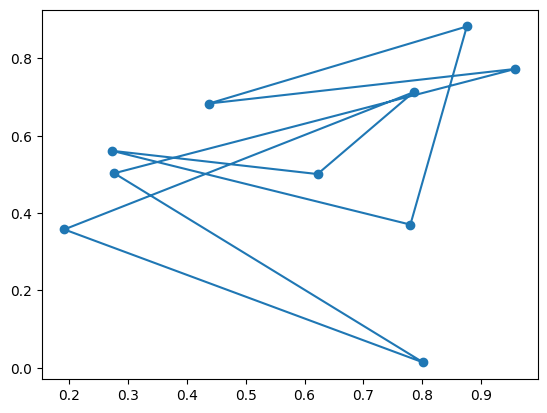

In [12]:
def show_tsp(tsp, tour=None):
    """display the traveling salesman problem and a tour."""

    pos = tsp["pos"]

    plt.scatter(pos["x"], pos["y"])

    if tour is not None:
        # make sure tour is a Python list (not an array or a numpy.array)
        if not isinstance(tour, list):
            tour = tour.tolist()

        print(f"Tour length: {round(tour_length(tsp, tour), 2)}")

        pos_ = pos.reindex(tour)
        pos_ = pd.concat([pos_, pos_.head(1)])   # thay append bằng concat
        plt.plot(pos_["x"], pos_["y"])

    plt.show()

show_tsp(tsp, tour)

## Use R to find a solution

Load rpy2, make sure the R [TSP package](https://CRAN.R-project.org/package=TSP) is installed and prepare the distance matrix.

In [13]:
%load_ext rpy2.ipython

%R if(!"TSP" %in% rownames(installed.packages())) install.packages("TSP", repos="http://cran.us.r-project.org")
%R if(!"microbenchmark" %in% rownames(installed.packages())) install.packages("microbenchmark", repos="http://cran.us.r-project.org")

d = tsp["dist"]

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘iterators’, ‘foreach’

trying URL 'http://cran.us.r-project.org/src/contrib/iterators_1.0.14.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/foreach_1.5.2.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/TSP_1.2-5.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpDyItpL/downloaded_packages’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'http://cran.us.r-project.org/src/contrib/microbenchmark_1.5.0.tar.gz'
Content type 'application/x-gzip' length 61673 bytes (60 KB)
downloaded 60 KB


The downloaded source packages are in
	‘/tmp/RtmpDyItpL/downloaded_packages’


Solve the TSP using [`solve_TSP`](https://www.rdocumentation.org/packages/TSP/versions/1.1-10/topics/solve_TSP) with the default heuristic. Note that 2-opt is steepest ascend hill climbing with exchanging two cities. `rep = 10` means 10 random restarts.

In [14]:
%%R -i d -o tour

library("TSP")

tsp <- TSP(d)
print(tsp)

tour <- solve_TSP(tsp, rep = 10)
print(tour)

# R starts index with 1, but Python starts at 0
tour <- tour - 1L

object of class ‘TSP’ 
10 cities (distance ‘unknown’) 
object of class ‘TOUR’ 
result of method ‘arbitrary_insertion+two_opt_rep_10’ for 10 cities
tour length: 2.763574 


In addition: Warning message:
executing %dopar% sequentially: no parallel backend registered 


Tour length: 2.76


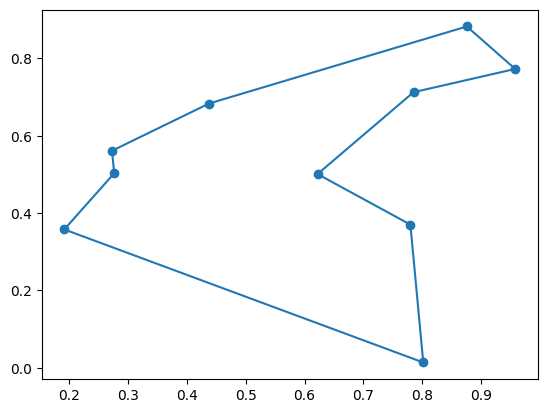

In [15]:
show_tsp(tsp, tour)

How long does it take to solve the problem?

In [16]:
%%R -i d

library("microbenchmark")
d <- TSP(d)


microbenchmark(solve_TSP(d, rep = 10))

Unit: milliseconds
                   expr     min       lq     mean   median       uq      max
 solve_TSP(d, rep = 10) 6.08588 6.473035 9.839512 9.879957 12.08225 17.46965
 neval
   100


## Steepest-ascend Hill Climbing Search [3 Points]

Calculate the objective function for all local moves (move each queen within its column) and always choose the best among all local moves.

In [17]:
# Code goes here
def steepest_ascent_hill_climbing(tsp, max_iterations=1000):
    """
    Steepest-ascent hill climbing: thử tất cả các local moves
    và chọn move tốt nhất (giảm độ dài tour nhiều nhất)
    """
    # Bắt đầu với một tour ngẫu nhiên
    current_tour = random_tour(len(tsp["pos"]))
    current_length = tour_length(tsp, current_tour)

    for iteration in range(max_iterations):
        # Tìm move tốt nhất trong tất cả các move có thể
        best_tour = current_tour
        best_length = current_length

        # Thử tất cả cặp vị trí có thể swap
        n = len(current_tour)
        for i in range(n):
            for j in range(i + 1, n):
                # Tạo tour mới bằng cách swap 2 thành phố
                new_tour = current_tour.copy()
                new_tour[i], new_tour[j] = new_tour[j], new_tour[i]

                # Tính độ dài tour mới
                new_length = tour_length(tsp, new_tour)

                # Nếu tour mới tốt hơn, lưu lại
                if new_length < best_length:
                    best_tour = new_tour
                    best_length = new_length

        # Nếu không tìm được tour tốt hơn, dừng lại (đã đạt local optimum)
        if best_length >= current_length:
            break

        # Cập nhật tour hiện tại
        current_tour = best_tour
        current_length = best_length

    return current_tour, current_length

## Steepest-ascend Hill Climbing Search with Random Restarts [1 Point]

Steepest-ascend with random restarts.

In [18]:
# Code goes here
def hill_climbing_random_restart(tsp, num_restarts=10):
    """
    Hill climbing với nhiều lần khởi động ngẫu nhiên
    để tránh bị kẹt ở local optimum
    """
    best_overall_tour = None
    best_overall_length = float('inf')

    # Thử nhiều lần với điểm xuất phát khác nhau
    for restart in range(num_restarts):
        # Chạy hill climbing từ điểm xuất phát ngẫu nhiên
        tour, length = steepest_ascent_hill_climbing(tsp)

        # Cập nhật kết quả tốt nhất
        if length < best_overall_length:
            best_overall_tour = tour
            best_overall_length = length

    return best_overall_tour, best_overall_length

## Stochastic Hill Climbing [1 Points]

Chooses randomly from among all uphill moves.

In [19]:
# Code goes here
def stochastic_hill_climbing(tsp, max_iterations=1000):
    """
    Stochastic hill climbing: chọn NGẪU NHIÊN trong các move
    làm giảm độ dài tour (thay vì chọn move tốt nhất)
    """
    # Bắt đầu với tour ngẫu nhiên
    current_tour = random_tour(len(tsp["pos"]))
    current_length = tour_length(tsp, current_tour)

    for iteration in range(max_iterations):
        # Lưu tất cả các move tốt hơn
        improving_moves = []

        # Thử tất cả cặp vị trí có thể swap
        n = len(current_tour)
        for i in range(n):
            for j in range(i + 1, n):
                # Tạo tour mới
                new_tour = current_tour.copy()
                new_tour[i], new_tour[j] = new_tour[j], new_tour[i]

                # Tính độ dài
                new_length = tour_length(tsp, new_tour)

                # Nếu tốt hơn, thêm vào danh sách
                if new_length < current_length:
                    improving_moves.append((new_tour, new_length))

        # Nếu không có move nào tốt hơn, dừng lại
        if len(improving_moves) == 0:
            break

        # Chọn NGẪU NHIÊN một move từ các move tốt hơn
        random_index = random.randint(0, len(improving_moves) - 1)
        current_tour, current_length = improving_moves[random_index]

    return current_tour, current_length

## Stochastic Hill Climbing (First-choice) [1 Point]

First-choice hill climbing is a type of stochastic hill climbing that generates one random local neighbor at a time and accept it if it has a better objective function value than the current state.

### Local Moves
I implement the following three different local move strategies:
* Swap two random cities.
* Swap two neighboring cities.
* Reverse the subtour between two cities.

In [20]:
def move_swap(tour):
    new_tour = tour.copy()

    # np.random.randint is inclusive lower limit and exclusive upper limit
    [a, b] = np.random.randint(0, len(tour), 2)
    #print(f"a={a}, b={b}")

    new_tour[a] = tour[b]
    new_tour[b] = tour[a]
    return(new_tour)

print(move_swap(list(range(10))))
print(move_swap(list(range(10))))
print(move_swap(list(range(10))))

[7, 1, 2, 3, 4, 5, 6, 0, 8, 9]
[9, 1, 2, 3, 4, 5, 6, 7, 8, 0]
[0, 1, 3, 2, 4, 5, 6, 7, 8, 9]


In [21]:
def move_swap_neighbors(tour):
    new_tour = tour.copy()

    a = np.random.randint(0, len(tour)-1, 1)[0]
    if a > 0: b = a+1
    else: b = len(tour)-1
    #print(f"a={a}, b={b}")

    new_tour[a] = tour[b]
    new_tour[b] = tour[a]
    return(new_tour)

print(move_swap_neighbors(list(range(10))))
print(move_swap_neighbors(list(range(10))))
print(move_swap_neighbors(list(range(10))))

[0, 1, 2, 4, 3, 5, 6, 7, 8, 9]
[0, 2, 1, 3, 4, 5, 6, 7, 8, 9]
[0, 1, 2, 4, 3, 5, 6, 7, 8, 9]


In [22]:
def move_reverse(tour):
    new_tour = tour.copy()

    ab = np.random.randint(0, len(tour)+1, 2)
    ab.sort()
    #print(f"a={ab[0]}, b={ab[1]}")

    new_tour[ab[0]:ab[1]] = new_tour[ab[0]:ab[1]][::-1]
    return(new_tour)

print(move_reverse(list(range(10))))
print(move_reverse(list(range(10))))
print(move_reverse(list(range(10))))

[0, 9, 8, 7, 6, 5, 4, 3, 2, 1]
[0, 1, 2, 6, 5, 4, 3, 7, 8, 9]
[0, 9, 8, 7, 6, 5, 4, 3, 2, 1]


### Search Algorithm

I don't know what the optimal tour is so I run the algorithm for at most `max_steps` steps, and stop if there is no improvement for at least `stop_after` steps.

In [23]:
def FCSHC(tsp, tour = None, local_move_method = move_swap,
         max_steps = 1000000, stop_after = 1000, verbose = True, keep_history = False):

    n = len(tsp['pos'])

    if keep_history: history = list()

    # 1. initialize current tour
    # current tour = initial tour (random if no tour is given)
    if not tour is None:
        current_tour = tour
    else:
        current_tour = random_tour(n)


    # initial tour length
    current_length = tour_length(tsp, current_tour)
    if verbose: print(f"initial tour length: {current_length}")

    # step when we last improved the length
    last_improvement_step = 0

    # 2. repeat local moves
    for step in range(max_steps):

        new_tour = local_move_method(current_tour)
        new_length = tour_length(tsp, new_tour)

        # check if the new tour is better
        if new_length < current_length:
            current_tour = new_tour
            current_length = new_length
            last_improvement_step = step
            if verbose: print(f"step: {step} - new tour length: {current_length}")

        if keep_history: history.append(current_length)

        # stop if we did not improve for stop_after steps
        if step - last_improvement_step > stop_after:
            if verbose: print(f"step: {step} - no improvement for {stop_after} steps.")
            break


    if keep_history: return(current_tour, history)
    return(current_tour)

### Comparison of Local Move Strategies Using a Single Problem

Tour length: 4.77


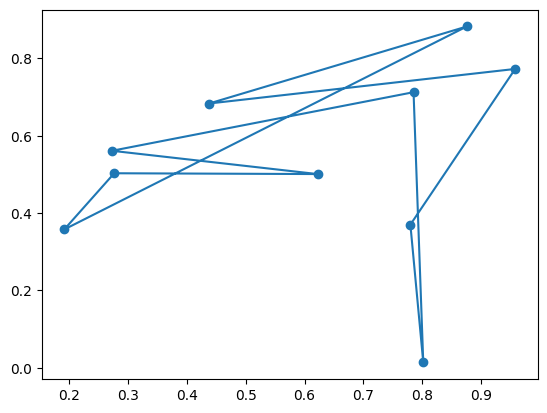

In [24]:
initial_tour = random_tour(len(tsp['pos']))
show_tsp(tsp, initial_tour)

initial tour length: 4.771643905788757
step: 2 - new tour length: 4.548343333711973
step: 4 - new tour length: 4.0996626793972055
step: 5 - new tour length: 3.866186468926611
step: 12 - new tour length: 3.844289924025318
step: 15 - new tour length: 3.042345144195955
step: 21 - new tour length: 2.8701519385212504
step: 23 - new tour length: 2.8536471173720015
step: 53 - new tour length: 2.822090126858674
step: 99 - new tour length: 2.805585305709425
step: 1100 - no improvement for 1000 steps.
CPU times: user 35.5 ms, sys: 8.07 ms, total: 43.5 ms
Wall time: 39.6 ms
Tour length: 2.81


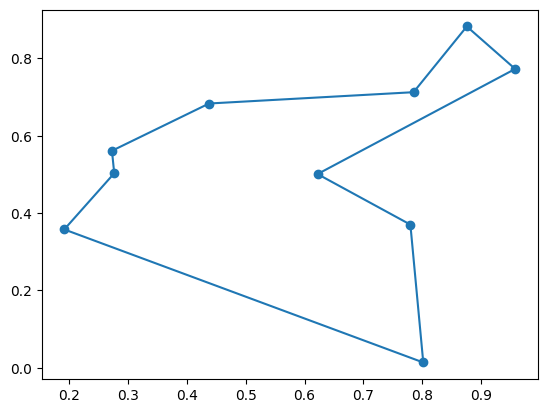

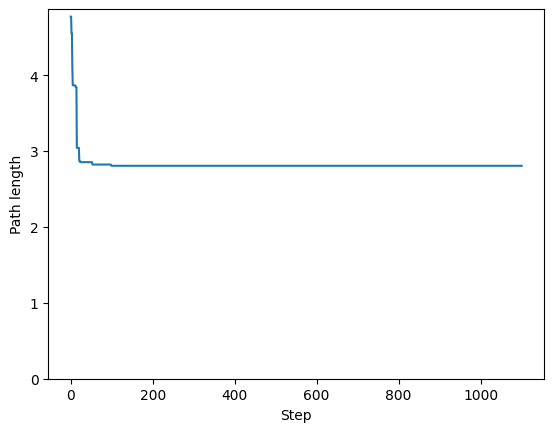

In [25]:
%time tour, history_swap = FCSHC(tsp, initial_tour, local_move_method = move_swap, keep_history = True)
show_tsp(tsp, tour)

plt.plot(range(len(history_swap)), history_swap)
plt.xlabel("Step")
plt.ylabel("Path length")
plt.ylim(bottom = 0)
plt.show()

initial tour length: 4.771643905788757
step: 0 - new tour length: 4.7466469542928955
step: 2 - new tour length: 4.701817514554664
step: 6 - new tour length: 3.8433952358946906
step: 1007 - no improvement for 1000 steps.
CPU times: user 17.3 ms, sys: 0 ns, total: 17.3 ms
Wall time: 17.5 ms
Tour length: 3.84


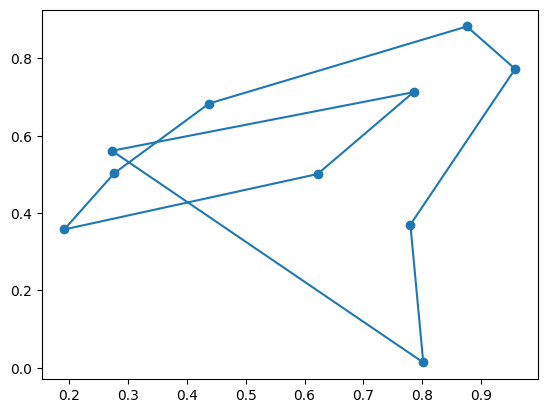

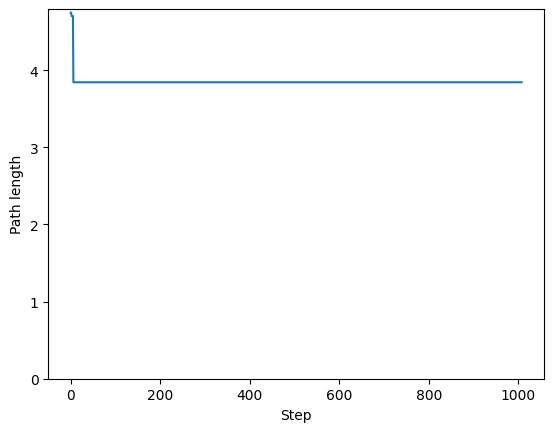

In [26]:
%time tour, history_swap_neighbors = FCSHC(tsp, initial_tour, local_move_method = move_swap_neighbors, keep_history = True)
show_tsp(tsp, tour)

plt.plot(range(len(history_swap_neighbors)), history_swap_neighbors)
plt.xlabel("Step")
plt.ylabel("Path length")
plt.ylim(bottom = 0)
plt.show()

initial tour length: 4.771643905788757
step: 5 - new tour length: 4.451168880891922
step: 7 - new tour length: 4.440238803473355
step: 12 - new tour length: 3.938070593768253
step: 16 - new tour length: 3.9006602904212873
step: 19 - new tour length: 3.8701392717007406
step: 20 - new tour length: 3.8038399913381187
step: 29 - new tour length: 3.7341277653585556
step: 32 - new tour length: 3.4895476028565793
step: 35 - new tour length: 3.322210764970703
step: 43 - new tour length: 3.304296646164533
step: 52 - new tour length: 2.8536471173720015
step: 99 - new tour length: 2.805585305709425
step: 1100 - no improvement for 1000 steps.
CPU times: user 33.9 ms, sys: 75 µs, total: 34 ms
Wall time: 36.8 ms
Tour length: 2.81


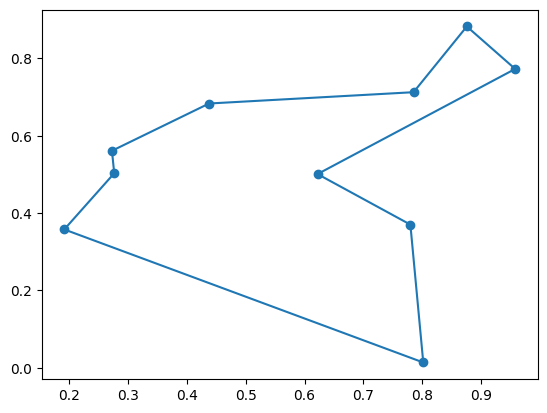

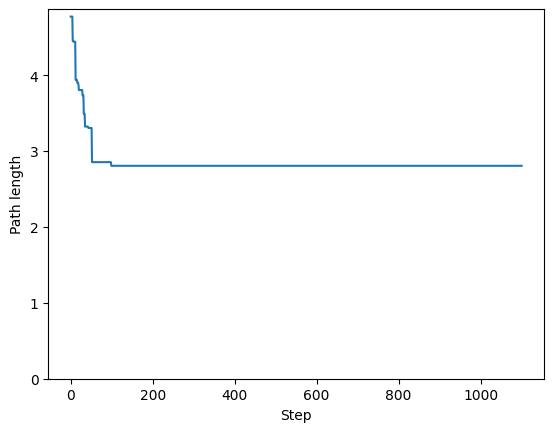

In [27]:
%time tour, history_reverse = FCSHC(tsp, initial_tour, local_move_method = move_reverse, keep_history = True)
show_tsp(tsp, tour)

plt.plot(range(len(history_reverse)), history_reverse)
plt.xlabel("Step")
plt.ylabel("Path length")
plt.ylim(bottom = 0)
plt.show()

All three learning curves

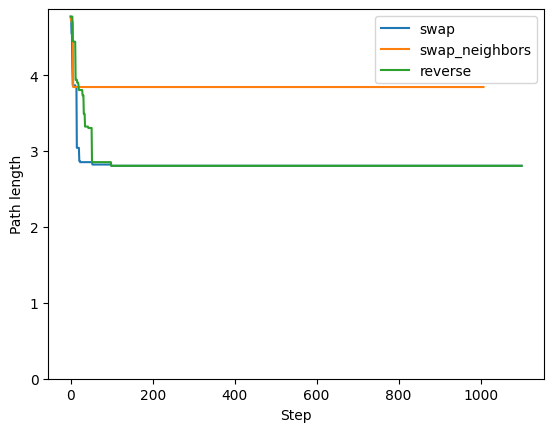

In [28]:
plt.plot(range(len(history_swap)), history_swap, label = "swap")
plt.plot(range(len(history_swap_neighbors)), history_swap_neighbors, label = "swap_neighbors")
plt.plot(range(len(history_reverse)), history_reverse, label = "reverse")
plt.xlabel("Step")
plt.ylabel("Path length")
plt.ylim(bottom = 0)
plt.legend()
plt.show()

### Comparison of Local Move Strategies

We compare the local move strategies using 100 random problems.

In [29]:
N = 100 # replications
n = 20 # number of cities

results = {
    'swap' : np.zeros(shape = [N]),
    'swap_neighbors' : np.zeros(shape = [N]),
    'reverse' : np.zeros(shape = [N])
}

for i in range(N):
    tsp_test = random_tsp(n)
    initial_tour = random_tour(n)

    results['swap'][i] = tour_length(tsp_test,
        FCSHC(tsp_test, initial_tour, local_move_method = move_swap, verbose = False))

    results['swap_neighbors'][i] = tour_length(tsp_test,
        FCSHC(tsp_test, initial_tour, local_move_method = move_swap_neighbors, verbose = False))

    results['reverse'][i] = tour_length(tsp_test,
        FCSHC(tsp_test, initial_tour, local_move_method = move_reverse, verbose = False))

    swap  swap_neighbors  reverse
0   3.78            7.92     3.90
1   4.24            8.97     4.29
2   4.81            8.04     3.78
3   4.42            8.64     3.39
4   4.48            7.72     4.19
..   ...             ...      ...
95  4.60            7.40     3.78
96  4.98            6.60     4.13
97  4.20            7.69     4.02
98  3.74            7.62     3.42
99  4.08            8.54     4.02

[100 rows x 3 columns]
swap              4.56
swap_neighbors    8.20
reverse           3.93
dtype: float64


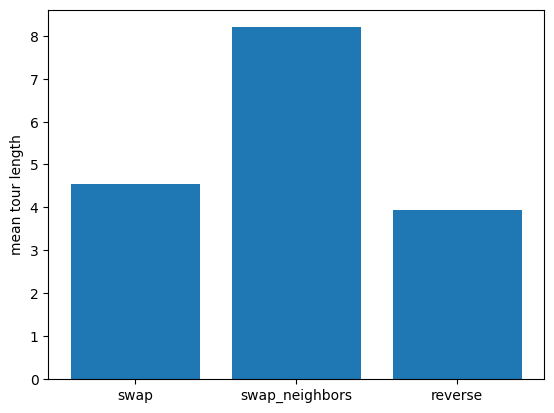

In [30]:
# compare averages
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(results)
print(results)

means = np.mean(results, axis = 0)
print(means)

plt.bar(means.keys(), means)
plt.ylabel("mean tour length")
plt.show()


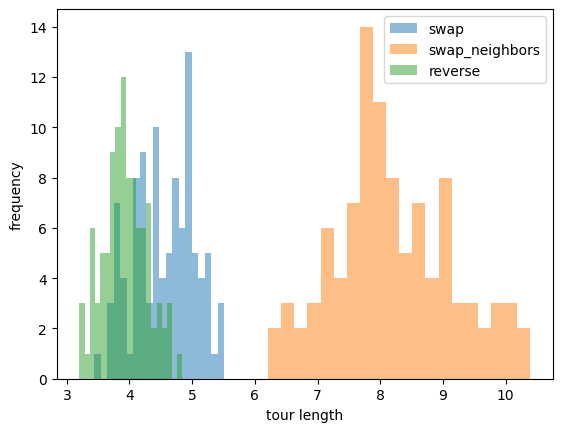

In [31]:
# histogram

plt.hist(results['swap'], bins = 20, alpha = .5)
plt.hist(results['swap_neighbors'], bins = 20, alpha = .5)
plt.hist(results['reverse'], bins = 20, alpha = .5)
plt.xlabel("tour length")
plt.ylabel("frequency")
plt.legend(labels = ["swap", "swap_neighbors", "reverse"])
plt.show()

<Axes: >

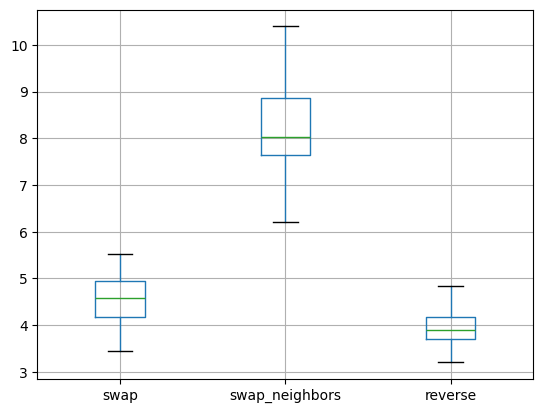

In [32]:
# boxplot (from pandas.DataFrame)

results.boxplot()

In [33]:
# is reverse better than swap?
# perform a paired t-test

from scipy import stats

stats.ttest_rel(results['swap'], results['reverse'])

TtestResult(statistic=np.float64(13.628841392608269), pvalue=np.float64(1.9136962197801338e-24), df=np.int64(99))

## Simulated Annealing [2 Points]

Simulated annealing is a form of stochastic hill climbing that also allows downhill moves with a probability proportional to the temperature. This is done to avoid local optima. The temperature is decreased in every iteration following an annealing schedule.

Finding a good cooling schedule for the problem is the most challenging part of simulated annealing. Some guidance can be found [here](http://what-when-how.com/artificial-intelligence/a-comparison-of-cooling-schedules-for-simulated-annealing-artificial-intelligence/).

The initial temperature $T_0$ should be chosen such that initially any move, no matter how bad, has a high probability of being performed. For $P = exp(-\Delta E/T_0)$ we get a probability of $exp(-1) = 0.37$ if $T_0$ is equal to the worst $\Delta E$. This is typically enough.

For the schedule, $T_t = T_0 \alpha^t$ is popular with $\alpha$ less but close to 1 and $t$ being the time step. Note that this is equivalent to multiplying the current temperature with $\alpha$ at every step.

In [34]:
def schedule(t, T0, alpha):
    return(T0 * alpha ** t)

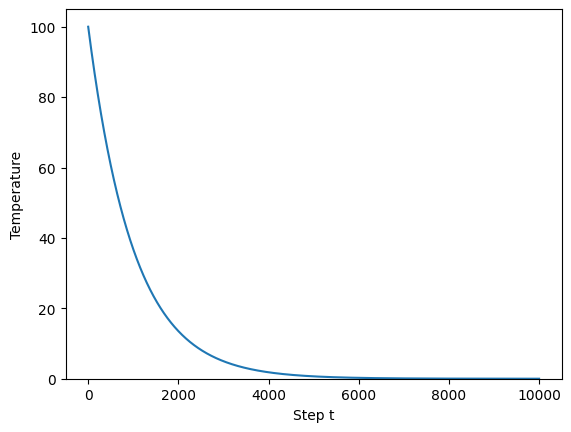

In [35]:
ts = range(0,10000)
plt.plot(ts, [schedule(t, 100, 0.999) for t in ts])
plt.xlabel("Step t")
plt.ylabel("Temperature")
plt.ylim(bottom = 0)
plt.show()

In [36]:
def SA(tsp, tour = None, local_move_method = move_reverse,
         T0 = None, alpha = 0.999, epsilon = 1e-3, verbose = True, keep_history = False):

    n = len(tsp['pos'])

    if keep_history: history = list()

    # 1. initialize current tour
    # current tour = initial tour (random if no tour is given)
    if not tour is None:
        current_tour = tour
    else:
        current_tour = random_tour(n)

    # initial tour length
    current_length = tour_length(tsp, current_tour)
    if verbose: print(f"initial tour length: {current_length:3.3}")

    # use the worst case length. We use the maximal distance for each row of the distance matrix.
    # This may not be a valid tour, but it is an upper limit for deltaE.
    if T0 is None:
        T0 = np.sum(np.amax(tsp["dist"], axis = 0))

    # 2. repeat local moves till temperature is low enough
    T = T0
    t = 0
    while T > epsilon:

        # calculate temperature from schedule
        T = schedule(t, T0, alpha)

        # create random move
        new_tour = local_move_method(current_tour)
        new_length = tour_length(tsp, new_tour)

        deltaE = new_length - current_length

        # check if the new tour is better
        if deltaE < 0 or np.random.rand() < math.exp(-deltaE/T):
            current_tour = new_tour
            current_length = new_length
            if verbose: print(f"step: {t} \t temp: {T:5.3f} \t deltaE: {deltaE:+3.3f} \t new tour length: {current_length:3.3f}")

        if keep_history: history.append(current_length)

        t += 1

    if keep_history: return(current_tour, history)
    return(current_tour)

CPU times: user 1.65 s, sys: 9.85 ms, total: 1.65 s
Wall time: 1.66 s
Tour length: 2.76


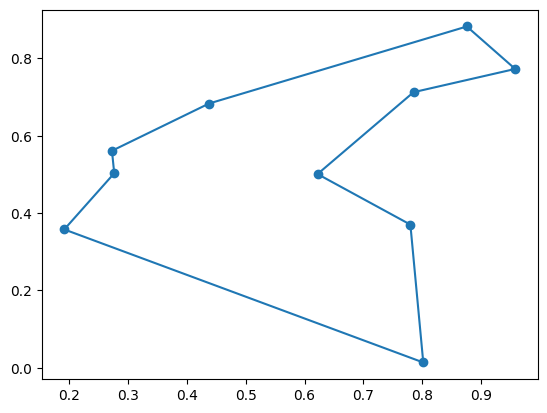

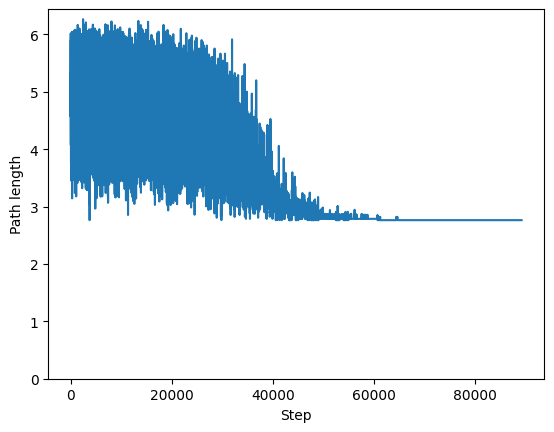

In [37]:
%time tour, history = SA(tsp, local_move_method = move_swap, alpha = 0.9999, verbose = False, keep_history = True)
show_tsp(tsp, tour)

plt.plot(range(len(history)), history)
plt.xlabel("Step")
plt.ylabel("Path length")
plt.ylim(bottom = 0)
plt.show()

## Compare Performance [2 Points]

Use runtime, scalability (number of cities), and best objective function value to compare the algorithms on boards of different sizes.  

For timing you can use the `time` package.

In [38]:
import time

t0 = time.time()
print("Do something")
t1 = time.time()

print(f"This took: {(t1-t0) * 1e3} milliseconds")

Do something
This took: 0.1513957977294922 milliseconds


In [39]:
# Code and results go here
# So sánh nhanh giữa các thuật toán local search

# Các thuật toán muốn so sánh - gọi trực tiếp các hàm đã định nghĩa trong notebook
algorithms = {
    "Steepest" : steepest_ascent_hill_climbing,
    "Stochastic" : stochastic_hill_climbing,
    "RandRestart" : hill_climbing_random_restart,
    "SimAnneal_swap" : (lambda tsp: SA(tsp, local_move_method = move_swap, verbose = False)),
    "SimAnneal_reverse" : (lambda tsp: SA(tsp, local_move_method = move_reverse, verbose = False))
}

# Các kích thước bài toán và số lần lặp (để kết quả nhanh, đặt nhỏ; tăng số lần lặp khi chạy thực nghiệm lớn)
sizes = [10, 15, 20]
reps = 8  # số lần lặp cho mỗi cấu hình (để chạy nhanh để demo)

rows = []
for n in sizes:
    for r in range(reps):
        tsp_inst = random_tsp(n)  # tạo 1 bài toán ngẫu nhiên
        for name, algo in algorithms.items():
            t0 = time.time()
            # Các hàm trả về (tour, length) hoặc chỉ tour; xử lý cả hai trường hợp
            out = algo(tsp_inst)
            t1 = time.time()
            duration_ms = (t1 - t0) * 1000.0

            # Nếu thuật toán trả về tuple (tour, length) thì lấy length, ngược lại tính lại
            if isinstance(out, tuple) and len(out) >= 2:
                tour, length = out[0], out[1]
            else:
                tour = out
                length = tour_length(tsp_inst, tour)

            rows.append({
                "algo": name,
                "n_cities": n,
                "rep": r,
                "time_ms": duration_ms,
                "length": length
            })

df = pd.DataFrame(rows)
# In bảng tóm tắt: trung bình và độ lệch chuẩn của thời gian và độ dài đường đi
summary = df.groupby(["algo", "n_cities"]).agg(
    mean_time_ms = ("time_ms", "mean"),
    std_time_ms = ("time_ms", "std"),
    mean_length = ("length", "mean"),
    std_length = ("length", "std"),
    runs = ("rep", "count")
).reset_index()

print("--- Tóm tắt nhanh (mean ± std) ---")
for _, row in summary.iterrows():
    print(f"{row['algo']:15s} | n={int(row['n_cities'])} | time={row['mean_time_ms']:.1f}±{(row['std_time_ms'] or 0):.1f} ms | length={row['mean_length']:.3f}±{(row['std_length'] or 0):.3f}")

# Hiển thị bảng pandas để dễ nhìn
display(summary.style.format({
    "mean_time_ms":"{:.1f}",
    "std_time_ms":"{:.1f}",
    "mean_length":"{:.3f}",
    "std_length":"{:.3f}"
}))

--- Tóm tắt nhanh (mean ± std) ---
RandRestart     | n=10 | time=8.3±0.5 ms | length=2.830±0.563
RandRestart     | n=15 | time=47.3±10.9 ms | length=3.373±0.368
RandRestart     | n=20 | time=195.2±81.7 ms | length=4.119±0.335
SimAnneal_reverse | n=10 | time=165.5±10.1 ms | length=2.839±0.566
SimAnneal_reverse | n=15 | time=180.7±17.0 ms | length=3.409±0.379
SimAnneal_reverse | n=20 | time=252.9±74.0 ms | length=4.072±0.382
SimAnneal_swap  | n=10 | time=163.3±8.7 ms | length=2.852±0.577
SimAnneal_swap  | n=15 | time=172.8±6.2 ms | length=3.415±0.430
SimAnneal_swap  | n=20 | time=236.4±59.4 ms | length=4.382±0.551
Steepest        | n=10 | time=0.9±0.2 ms | length=2.857±0.573
Steepest        | n=15 | time=4.5±1.0 ms | length=3.794±0.315
Steepest        | n=20 | time=21.5±6.4 ms | length=4.597±0.500
Stochastic      | n=10 | time=1.5±0.6 ms | length=2.883±0.594
Stochastic      | n=15 | time=8.7±3.0 ms | length=3.919±0.657
Stochastic      | n=20 | time=43.9±21.4 ms | length=5.098±0.659


,algo,n_cities,mean_time_ms,std_time_ms,mean_length,std_length,runs
0,RandRestart,10,8.3,0.5,2.830,0.563,8
1,RandRestart,15,47.3,10.9,3.373,0.368,8
2,RandRestart,20,195.2,81.7,4.119,0.335,8
3,SimAnneal_reverse,10,165.5,10.1,2.839,0.566,8
4,SimAnneal_reverse,15,180.7,17.0,3.409,0.379,8
5,SimAnneal_reverse,20,252.9,74.0,4.072,0.382,8
6,SimAnneal_swap,10,163.3,8.7,2.852,0.577,8
7,SimAnneal_swap,15,172.8,6.2,3.415,0.430,8
8,SimAnneal_swap,20,236.4,59.4,4.382,0.551,8
9,Steepest,10,0.9,0.2,2.857,0.573,8


## Bonus: Genetic Algorithm [+1 Point]

GA demo: length=4.007, time=0.081s
Tour length: 4.01


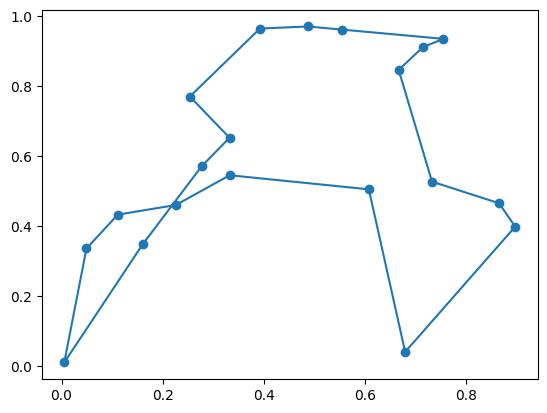

In [40]:
# Code goes here
# Một cài đặt đơn giản của Genetic Algorithm cho TSP
import random, time

def order_crossover(p1, p2):
    """Order Crossover (OX) - trả về 2 con cái"""
    n = len(p1)
    a, b = sorted(random.sample(range(n), 2))
    child1 = [-1]*n
    child2 = [-1]*n
    # copy đoạn giữa
    child1[a:b+1] = p1[a:b+1]
    child2[a:b+1] = p2[a:b+1]
    # helper để fill the rest preserving order
    def fill_child(child, parent_other):
        cur = (b+1) % n
        for i in range(n):
            idx = (b+1 + i) % n
            gene = parent_other[idx]
            if gene not in child:
                child[cur] = gene
                cur = (cur + 1) % n
        return child
    child1 = fill_child(child1, p2)
    child2 = fill_child(child2, p1)
    return child1, child2

def swap_mutation(tour):
    """Đổi chỗ 2 thành phần (swap)"""
    a, b = random.sample(range(len(tour)), 2)
    tour[a], tour[b] = tour[b], tour[a]
    return tour

def tournament_select(pop, fitnesses, k=3):
    """Lấy 1 cá thể bằng tournament selection"""
    idxs = random.sample(range(len(pop)), k)
    best = idxs[0]
    for idx in idxs[1:]:
        if fitnesses[idx] > fitnesses[best]:
            best = idx
    return pop[best]

def genetic_algorithm_tsp(tsp, pop_size=40, generations=150, cx_prob=0.8, mut_prob=0.2, elite=1):
    """Trả về (best_tour, best_length)"""
    n = len(tsp["pos"])
    # 1) khởi tạo quần thể
    pop = [random_tour(n) for _ in range(pop_size)]
    # 2) đánh giá
    def eval_pop(pop):
        lengths = [tour_length(tsp, ind) for ind in pop]
        fitnesses = [1.0/l for l in lengths]  # fitness = 1/length
        return lengths, fitnesses
    lengths, fitnesses = eval_pop(pop)
    best_idx = min(range(len(lengths)), key=lambda i: lengths[i])
    best_tour = pop[best_idx].copy()
    best_length = lengths[best_idx]

    # tiến hoá
    for gen in range(generations):
        new_pop = []
        # elitism: giữ elite cá thể tốt nhất
        sorted_idx = sorted(range(len(lengths)), key=lambda i: lengths[i])
        for i in range(elite):
            new_pop.append(pop[sorted_idx[i]].copy())

        while len(new_pop) < pop_size:
            # chọn cha mẹ
            p1 = tournament_select(pop, fitnesses, k=3)
            p2 = tournament_select(pop, fitnesses, k=3)
            # crossover
            if random.random() < cx_prob:
                c1, c2 = order_crossover(p1, p2)
            else:
                c1, c2 = p1.copy(), p2.copy()
            # mutation
            if random.random() < mut_prob:
                c1 = swap_mutation(c1)
            if random.random() < mut_prob:
                c2 = swap_mutation(c2)
            new_pop.append(c1)
            if len(new_pop) < pop_size:
                new_pop.append(c2)
        pop = new_pop
        lengths, fitnesses = eval_pop(pop)
        # cập nhật best
        idx = min(range(len(lengths)), key=lambda i: lengths[i])
        if lengths[idx] < best_length:
            best_length = lengths[idx]
            best_tour = pop[idx].copy()
        # (không in quá nhiều để tránh làm chậm) - có thể in 1 dòng mỗi vài thế hệ nếu muốn

    return best_tour, best_length

# Demo chạy GA trên 1 bài toán nhỏ để minh họa
tsp_demo = random_tsp(20)
t0 = time.time()
best_tour, best_len = genetic_algorithm_tsp(tsp_demo, pop_size=40, generations=120, cx_prob=0.85, mut_prob=0.25, elite=1)
t1 = time.time()
print(f"GA demo: length={best_len:.3f}, time={(t1-t0):.3f}s")
show_tsp(tsp_demo, best_tour)